## <h1 style="color: aqua;">Welcome to my Project!!!</h1>

##### The goal of this project is to examine Tornado Strength, occurence and geographic impact across the United States. Our overall goal is to answer the question "Is Tornado Alley shifting eastward?" This is a common belief and conclusion in the meterological community, but, taking an analytical approach lets us visualize if such claims are true. To do so, we will investigate tornado impacts once a decade (2004, 2014, 2024). Before we touch any data, it is critical to understand what exactly the data is. I have created a small table below to reference what the column names in the dataset mean.



##### **NOAA/NCEI Storm Events Column Reference**

**Tornado:** `TOR_F_SCALE` (Fujita rating) · `TOR_SCALE_UNIFIED` (EF scale) · `TOR_LENGTH` (miles) · `TOR_WIDTH` (yards) · `TOR_OTHER_WFO` (other forecast office) · `TOR_OTHER_CZ_STATE` (other state affected)

**Location:** `CZ_TYPE` (C=County, Z=Zone) · `CZ_FIPS` (county code) · `CZ_NAME` (county/zone name) · `STATE_FIPS` (state code) · `WFO` (forecast office)

**Time:** `BEGIN_YEARMONTH` (YYYYMM) · `BEGIN_DAY` · `BEGIN_TIME` (HHMM) · `END_YEARMONTH` · `END_DAY` · `END_TIME`

**Damage/Casualties:** `INJURIES_DIRECT` · `INJURIES_INDIRECT` · `DEATHS_DIRECT` · `DEATHS_INDIRECT` · `DAMAGE_PROPERTY` · `DAMAGE_CROPS`

**Event:** `EVENT_ID` (unique ID) · `EPISODE_ID` (groups related events) · `EVENT_TYPE` · `SOURCE` (reporter) · `MAGNITUDE` · `MAGNITUDE_TYPE`

##### **Please Review the Entity Relationship Diagram (ERD)!!** It is important to lay out how the data relates and how it should be organized. This ERD will be displayed in each section for reference. Lastly, before coding starts, it best practice to import the needed libraries.
![Tornado ERD](../Assets/Tornado_ERD.jpeg)

In [166]:
# Importing needed libraries!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

##### Our first step is to create a function that imports the data, as well as cleans it. The CSVs gathered from NOAA are quite massive, and have many more columns that we do not need. Based on upon our Entity Relationship Diagram (ERD), we only concerend with the following fields: event_id, state, tor_scale_unified, tor_length, tor_width, year, injuries, fatailites.

In [167]:
def clean_tornado_data(csv_path): # Defining the function
    df = pd.read_csv(csv_path) # Pandas read function 

    df = df[df['EVENT_TYPE'].str.lower() == 'tornado'].copy() # The data contains more than just tornadoes, but we are only interested in tornadoes. Therefore, event types must be filtered to tornadoes, and stripped of any capital letters for an accurate measure.

    # Extract year from BEGIN_YEARMONTH, as our ERD calls for only the year.
    df['BEGIN_YEARMONTH'] = df['BEGIN_YEARMONTH'].astype(str) # Changing data type to string
    df['year'] = df['BEGIN_YEARMONTH'].str[:4].astype(int) # Define year as an integer, and use splicing to grab only the year.
    df.drop(columns=['BEGIN_YEARMONTH'], inplace=True) # Drop the now unneeded 'BEGIN_YEARMONTH' column

    # Dropping extra or unneeded columns
    cols_to_drop = [
        'TOR_OTHER_WFO', 'TOR_OTHER_CZ_STATE', 'TOR_OTHER_CZ_FIPS', 'TOR_OTHER_CZ_NAME',
        'CATEGORY', 'FLOOD_CAUSE', 'MAGNITUDE_TYPE',
        'BEGIN_RANGE', 'BEGIN_AZIMUTH', 'BEGIN_LOCATION', 'END_RANGE', 'END_AZIMUTH',
        'END_LOCATION', 'BEGIN_LAT', 'BEGIN_LON', 'END_LAT', 'END_LON',
        'DAMAGE_PROPERTY', 'DAMAGE_CROPS', 'EPISODE_ID', 'STATE_FIPS', 'CZ_NAME',
        'WFO', 'MAGNITUDE', 'DATA_SOURCE', 'EPISODE_NARRATIVE', 'EVENT_NARRATIVE',
        'EVENT_ID', 'BEGIN_DATE_TIME', 'CZ_TIMEZONE', 'END_DATE_TIME',
        'CZ_TYPE', 'CZ_FIPS', 'END_DAY', 'END_TIME', 'END_YEARMONTH',
        'SOURCE', 'MONTH_NAME', 'BEGIN_TIME', 'BEGIN_DAY', 'YEAR', 'EVENT_TYPE'
    ]

    df.drop(columns=cols_to_drop, inplace=True, errors='ignore')
    df.reset_index(drop=True, inplace=True) # Reset index

    # Combine injury and death columns, as NOAA lists them as both direct or indirect.
    df['injuries'] = df['INJURIES_DIRECT'] + df['INJURIES_INDIRECT']
    df['fatalities'] = df['DEATHS_DIRECT'] + df['DEATHS_INDIRECT']
    df.drop(columns=['INJURIES_DIRECT', 'INJURIES_INDIRECT', 'DEATHS_DIRECT', 'DEATHS_INDIRECT'], inplace=True)

    # Rename columns to match SQL schema based upon ERD (lower case).
    df.rename(columns={
        'STATE':            'state',
        'TOR_LENGTH':       'tor_length',
        'TOR_WIDTH':        'tor_width',
        'TOR_F_SCALE':      'tor_f_scale',
        'TOR_SCALE_UNIFIED': 'tor_scale_unified'
    }, inplace=True)

    # Converting tor_width from yards to miles for consistency with tor_length.
    df['tor_width'] = df['tor_width'] / 1760

    return df

##### We are going to us the OS library to scan for files before running CSVs through this function. I opted to use a "Warehouse" analogy for my understanding, it helps me visualize what the code is doing. This process is local to this notebook, as the data was gathered from three different CSVs files (2004, 2014, 2024). There are plenty of different ways to do this, but for me, the OS library with a for loop was the easiest strategy that made sense.


In [168]:
raw_dir = r"../Data/Raw_Tornado_Data" # Raw string > Telling Python where to grab the CSVs. We can think of this as the "warehouse" where the CSVs are stored. Note that it is a relative file path.

files = [
    os.path.join(raw_dir, f) # This will put the folder path mentioned above and file name together, similar to matching a customer to their box in the warehouse.
    for f in os.listdir(raw_dir) # Telling Windows to list every file in the folder. Keeping with the warehouse analogy, we are looking through the warehouse for boxes.
    if f.endswith(".csv") # Filter(only looks for CSV files). We only want boxes labeled "CSV" and nothing else.
]

files
#Lastly, files is the output of those files once Windows looks in the file path and filters. There are only CSVs files in here, but filtering is good practice. We now have 3 boxes with the following names listed below.

['../Data/Raw_Tornado_Data\\tornado_2004_raw_data.csv',
 '../Data/Raw_Tornado_Data\\tornado_2014_raw_data.csv',
 '../Data/Raw_Tornado_Data\\tornado_2024_raw_data.csv']

#### Now that the function is created, and we have made a loop to pull in CSVs, the hard part is done. We will just define a DataFrame, start the loop, and insert our fnction.

In [169]:
cleaned_dfs = [] # Creating an empty list/bucket.

for f in files: # Creating for loop to check for CSVs and cleaning them. Imagine opening the box and cleaning the contents.
    cleaned_dfs.append(clean_tornado_data(f)) # We use f (files) instead of the CSV file name as files was defined in the section above.

tornado_df = pd.concat(cleaned_dfs, ignore_index=True) # Concat those DFs into one DF. We have now cleaned the contents and put them into one big box.



In [170]:
tornado_df.head() # Checking the head to make sure everything is correct.

,state,tor_f_scale,tor_length,tor_width,year,injuries,fatalities
0,NEVADA,F0,0.1,0.113636,2004,0,0
1,CALIFORNIA,F0,0.2,0.001705,2004,0,0
2,MISSISSIPPI,F0,0.2,0.028409,2004,0,0
3,INDIANA,F0,1.5,0.042614,2004,0,0
4,HAWAII,F0,5.0,0.014205,2004,0,0


In [171]:
tornado_df.tail() # Checking the tail to make sure everything is correct.

,state,tor_f_scale,tor_length,tor_width,year,injuries,fatalities
5135,WISCONSIN,EF0,5.57,0.042614,2024,0,0
5136,WISCONSIN,EF1,5.26,0.056818,2024,0,0
5137,WISCONSIN,EF0,1.41,0.022727,2024,0,0
5138,MISSOURI,EFU,0.15,0.011364,2024,0,0
5139,FLORIDA,EF1,0.90,0.056818,2024,0,0


# <h2 style="color: orange;">Problem 1: Different units of measurement.</h2>

##### There are two different units of measurement, the Fujita scale and the Enchanced Fujita Scale. We would want them all to be under the same scale for consistency purposes, and we are relabeling them as such below. Note that the scales are not a direct 1:1 replacement, so relying on tornado strength via the scale rating would not be wise.

In [172]:
f_to_ef = {'F0':'EF0', 'F1':'EF1', 'F2':'EF2', 'F3':'EF3', 'F4':'EF4', 'F5':'EF5'} # Dictonary
tornado_df['tor_scale_unified'] = tornado_df['tor_f_scale'].replace(f_to_ef) # Taking old data frame and replacing F scale tornadoes with EF.
tornado_df.drop(columns=['tor_f_scale'], inplace=True) # Dropping old column of tornado scale since it is no longer needed.

# <h2 style="color: orange;">Problem 2: State names and abbreviations.</h2>


<h2 style="color: red;">⚠️ DISCLAIMER</h2>

##### We are going to convert the state names from their full name into their appriopate abbrevation for consistency sake and use with SQL. **ClaudeAI was used to facilitate and expedite this process**. Instead of manually creating the dictionary, I decided to let an AI perform this since the task is easy and could take a while. The basic idea is matching the state names with the correct two letters abbreviation.

**Example:**
```python
state_abbrev = {'KENTUCKY': 'KY'} # This would set the state of Kentucky to KY, this will need to be repeated for all 50 states.
```

In [173]:
state_abbrev = {
    'ALABAMA': 'AL', 'ALASKA': 'AK', 'ARIZONA': 'AZ', 'ARKANSAS': 'AR',
    'CALIFORNIA': 'CA', 'COLORADO': 'CO', 'CONNECTICUT': 'CT', 'DELAWARE': 'DE',
    'FLORIDA': 'FL', 'GEORGIA': 'GA', 'HAWAII': 'HI', 'IDAHO': 'ID',
    'ILLINOIS': 'IL', 'INDIANA': 'IN', 'IOWA': 'IA', 'KANSAS': 'KS',
    'KENTUCKY': 'KY', 'LOUISIANA': 'LA', 'MAINE': 'ME', 'MARYLAND': 'MD',
    'MASSACHUSETTS': 'MA', 'MICHIGAN': 'MI', 'MINNESOTA': 'MN', 'MISSISSIPPI': 'MS',
    'MISSOURI': 'MO', 'MONTANA': 'MT', 'NEBRASKA': 'NE', 'NEVADA': 'NV',
    'NEW HAMPSHIRE': 'NH', 'NEW JERSEY': 'NJ', 'NEW MEXICO': 'NM', 'NEW YORK': 'NY',
    'NORTH CAROLINA': 'NC', 'NORTH DAKOTA': 'ND', 'OHIO': 'OH', 'OKLAHOMA': 'OK',
    'OREGON': 'OR', 'PENNSYLVANIA': 'PA', 'PUERTO RICO': 'PR', 'RHODE ISLAND': 'RI',
    'SOUTH CAROLINA': 'SC', 'SOUTH DAKOTA': 'SD', 'TENNESSEE': 'TN', 'TEXAS': 'TX',
    'UTAH': 'UT', 'VIRGINIA': 'VA', 'WASHINGTON': 'WA', 'WEST VIRGINIA': 'WV',
    'WISCONSIN': 'WI', 'WYOMING': 'WY'
}

tornado_df['state'] = tornado_df['state'].map(state_abbrev)

# Eastern State?

We are now going to assign each state with the notation `is_eastern_shift_state`. We are making a **separate DataFrame** for this, as this will need to be its own table in SQL. States such as Texas (TX) are considered "Traditional Tornado Alley" states, while states such as Alabama (AL) will be noted as an eastern shift state.

Just like the code cell above, I am opting to use Claude AI to facilitate this process for time saving purposes. The basic syntax is as follows:

**Example:**
```python
state_regions_data = { 
    'state': ['KY'], # State is KY
    'region_name': ['Emerging'], # It is considered a "Emerging" tornado state according to NOAA.
    'is_eastern_shift_state': [1]
}
```

This syntax will be followed for all 50 states. Reminder that SQLite treats boolean true/false as `0` or `1`. `0` meaning False, `1` meaning True. In the example above, KY is noted as an eastern shift state with `1` and its `region_name` is set to `'Emerging'`.

There are also **Traditional** and **Other** region classifications. The "Other" category is for states that do not fall in Tornado Alley nor in the Emerging area. For example, while Washington (WA) can receive tornadoes, it does not fall into either category and its value is treated as `0` (False). Note that the column names align with the ERD lookup table.

In [174]:
state_regions_data = {
    'state': [
        'TX', 'OK', 'KS', 'NE', 'IA', 'SD', 'ND', 'MO',  # Traditional
        'MS', 'AL', 'TN', 'KY', 'AR', 'LA', 'GA', 'IN', 'OH', 'IL', 'NC', 'SC',  # Emerging
        'NV', 'CA', 'HI', 'VA', 'FL', 'NM', 'AZ', 'WI', 'WA', 'AK', 'MD',
        'MN', 'NY', 'CO', 'OR', 'MI', 'MT', 'PA', 'WY', 'WV', 'ID',
        'NH', 'ME', 'PR', 'DE', 'MA', 'NJ', 'CT', 'UT', 'RI'  # Other
    ],
    'region_name': [
        'Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional', 'Traditional',
        'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging', 'Emerging',
        'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other',
        'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other',
        'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other', 'Other'
    ],
    'is_eastern_shift_state': [
        0, 0, 0, 0, 0, 0, 0, 0,  # Traditional
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,  # Emerging
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0  # Other
    ]
}

state_regions_df = pd.DataFrame(state_regions_data)
pd.set_option('display.max_rows', 20) # Set max rows to 20
print(state_regions_df) # Printing the output for validation
state_regions_df.to_csv("../Data/Cleaned_Tornado_Data/eastern_state_notation.csv", index=False) # Saving to CSV file

   state  region_name  is_eastern_shift_state
0     TX  Traditional                       0
1     OK  Traditional                       0
2     KS  Traditional                       0
3     NE  Traditional                       0
4     IA  Traditional                       0
..   ...          ...                     ...
45    MA        Other                       0
46    NJ        Other                       0
47    CT        Other                       0
48    UT        Other                       0
49    RI        Other                       0

[50 rows x 3 columns]


##### Now that the data is cleaned, we can look at basic information, such as how many tornadoes per state in a given year

In [175]:
tornado_per_state = tornado_df.groupby(['year', 'state']).size() # Group by year and state, size represents the number of elements in a DataFrame
print(tornado_per_state)

year  state
2004  AK        2
      AL       65
      AR       58
      AZ        3
      CA       10
               ..
2024  VA       14
      WA        4
      WI       55
      WV       21
      WY        5
Length: 137, dtype: int64


##### We can also look at a particular state and compare how tornadoes have increased or decreased over the past three decades. This gives us a clean view if that state is confirmed to be an eastern shift state. As you can see below, the number of tornadoes in KY has more than doubled since 2004.

In [176]:
print(tornado_df[tornado_df['state'] == 'KY'].groupby('year').size()) # Size represents the number of elements in a DataFrame

year
2004    23
2014    29
2024    66
dtype: int64


In [177]:
tornado_df.to_csv("../Data/Cleaned_Tornado_Data/tornado_all_years_cleaned.csv", index=False) # Saving cleaned data to this directory with this file name.

<h2 style="color: violet;">Graphics and Illustrations (Exploratory Data Analysis)</h2>

The following diagrams below are some simple illustrations to help us understand the data. There are more graphs in the final notebook that are more conclusive, but these were created as a way to start with analyzing the data.

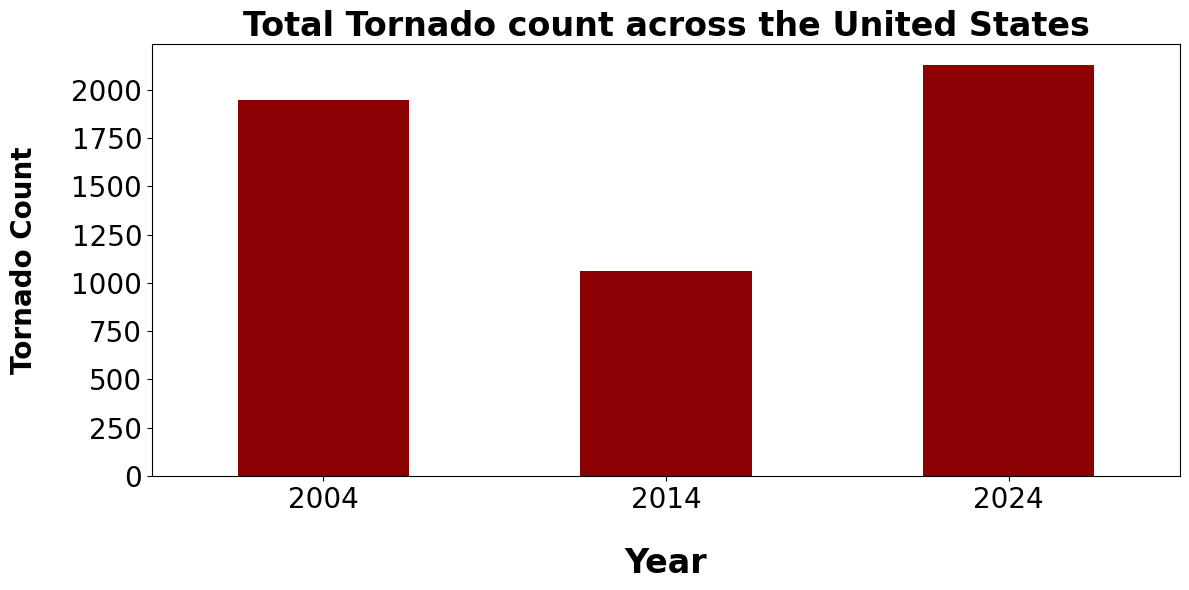

In [178]:
#Creating a bar graph showing Number of Tornadoes per year
tornado_per_year = tornado_df.groupby('year').size()

plt.figure(figsize=(12,6))
tornado_per_year.plot(kind='bar', color='darkred')
plt.title('Total Tornado count across the United States', fontsize=24, fontweight="bold")
plt.xlabel('Year',fontsize=24, fontweight="bold", labelpad=24)
plt.ylabel('Tornado Count', labelpad=24, fontsize=20, fontweight="bold")
plt.xticks(rotation=360, fontsize=20)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.show()


##### Tornado count slightly increased from 2004 to 2024, with a notable dip in 2014. This is likely an anomaly given the rebound in 2024. Next, we can look at tornado strength. Tornado path length serves as a more reliable indicator of strength than the EF scale. A line graph is used below to visualize trends across our three benchmark years.

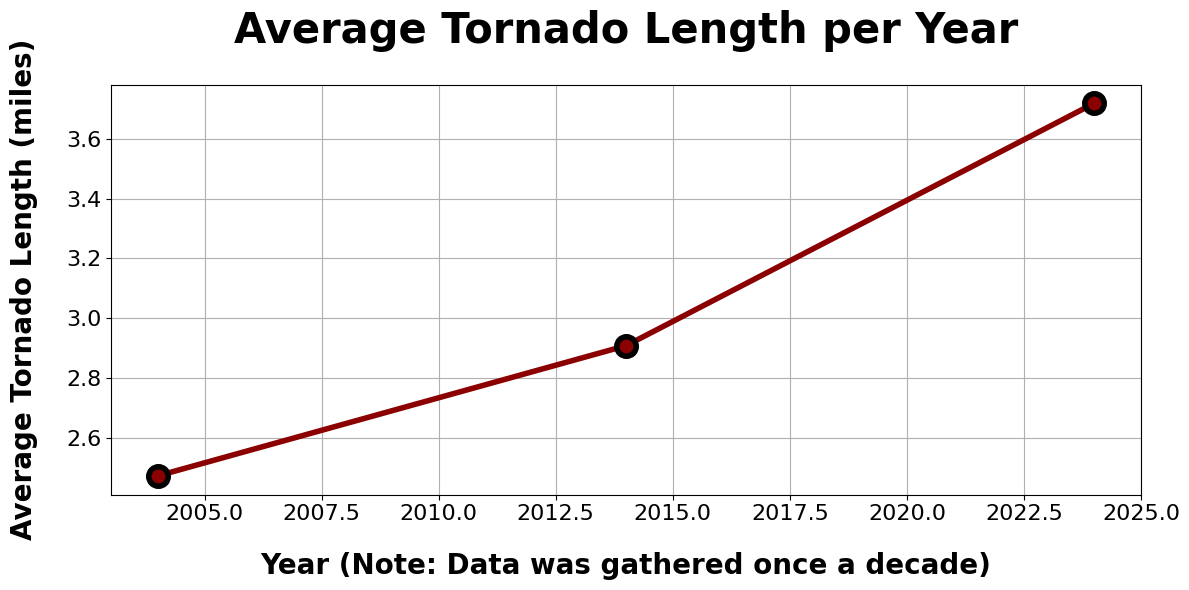

In [179]:
plt.figure(figsize=(12,6))

# Group by year and calculate average tornado length
avg_length_per_year = tornado_df.groupby('year')['tor_length'].mean()

plt.plot(avg_length_per_year.index, avg_length_per_year.values, marker='o', linewidth=4,color="darkred",markersize=14,markeredgecolor='Black',markeredgewidth=4)
plt.title('Average Tornado Length per Year',fontsize=30,pad=30,fontweight="bold")
plt.xlabel('Year (Note: Data was gathered once a decade)',fontsize=20,labelpad=20,fontweight="bold")
plt.xticks(rotation=360, fontsize=16)
plt.ylabel('Average Tornado Length (miles)',fontsize=20,labelpad=20,fontweight="bold")
plt.yticks(fontsize=16)
plt.grid(True)
plt.tight_layout()
plt.show()


##### Average tornado path length has steadily increased since 2004, growing nearly a mile over the benchmark period. Below we examine Kentucky (KY) specifically as a representative Eastern shift state, using a histogram to visualize the distribution of tornado lengths across all three benchmark years.

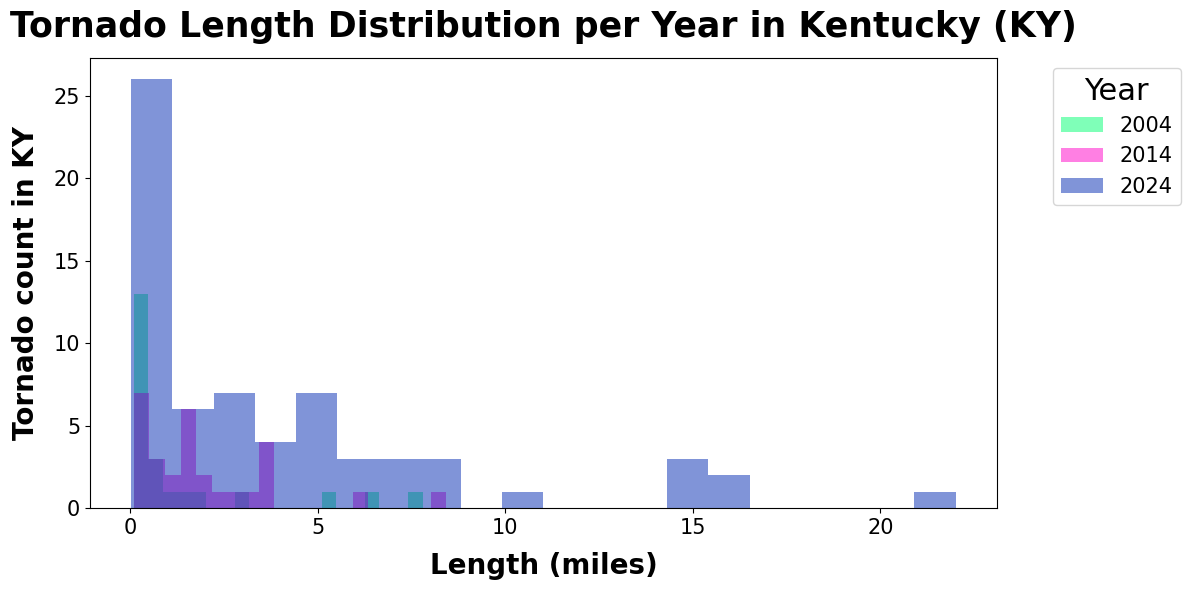

In [180]:
palette = [
    "#00FF73",
    "#FF01C8",
    "#022BB3",
    "#F4A261",
    "#E76F51"
]

df_ky = tornado_df[tornado_df['state'] == 'KY'] # Dataframe is equal to where state is KY
years = sorted(df_ky['year'].unique()) #Sorting by unique instances of tornadoes
               
plt.figure(figsize=(12,6))

for i, year in enumerate(years): #Since we are using specific colors, we use i / enumerate instead of a traditional for loop
    data = df_ky[df_ky['year'] == year]['tor_length']
    plt.hist(
        data,
        bins=20,
        alpha=0.5,
        color=palette[i % len(palette)],  
        label=str(year)
    )


plt.title('Tornado Length Distribution per Year in Kentucky (KY)',fontweight="bold",fontsize=25,pad=15)
plt.xlabel('Length (miles)',fontsize=20,fontweight="bold",labelpad=10)
plt.xticks(fontsize=15)
plt.ylabel('Tornado count in KY',fontsize=20,fontweight="bold",labelpad=10)
plt.yticks(fontsize=15)
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left',title_fontsize=22,fontsize=15,)
plt.tight_layout()
plt.show()
